In [1]:
import os
print(os.getcwd())

C:\Users\senas\Downloads


In [2]:
path = "C:\\Users\\senas\\Downloads" # Buraya kendi gerçek yolunu yaz
print("Bu klasörde bulunan dosyalar:", os.listdir(path))

Bu klasörde bulunan dosyalar: ['#diet #diyet #motivasyon #basari #hedef #kilo #yasam.jpg', '(663483)20211805010_20241024.pdf', '(Konu yok).zip', '...jpeg', '..jpeg', '.ipynb_checkpoints', '0+-+Yazilim+Test+Tarihi.pptx', '005056b8-44c0-1eee-9fe4-80bb363a72dd.xml', '005056b8-44c0-1eee-a4cd-789503bf32dd.xml', '01.11 ıt.docx', '01_2025.xlsx', '01_2026.xlsx', '02.10.docx', '02_2025.xlsx', '02_2026.xlsx', '03_2025.xlsx', '04.10 IT.docx', '04_2025.xlsx', '05_2025.xlsx', '06_2025.xlsx', '07_2025.xlsx', '08_2025.xlsx', '09_2025.xlsx', '1.4_video_slides_posted.pptx', '1.5.6698.doc', '1.5_video_slides_posted (1).pptx', '1.5_video_slides_posted.pptx', '1.6_video_slides_posted.pptx', '10.1007_s10198-023-01634-2-citation.ris', '1000070737.png', '1000070738.png', '1000070739.png', '100_6851.JPG', '10192-10193.pdf', '10_2025.xlsx', '11.10 IT.docx', '11.ay verileri.xlsx', '11_2025.xlsx', '12_2025.xlsx', '13.11 it321.docx', '14a17049-71da-4417-a07b-961f75a0070e (1).PDF', '14a17049-71da-4417-a07b-961f75a

In [3]:
import pandas as pd
import glob
import os

# "01_2025.xlsx" formatındaki tüm dosyaları bulur
files = glob.glob(os.path.join(path, "*_202*.xlsx"))

files = [f for f in files if "osf_2193681000" not in f]

# 2. İşlemi yapacak fonksiyonu tanımla
def process_energy_data(file_path):
    # Dosyayı oku
    df = pd.read_excel(file_path)

    # Maskeleme ve Kaydırma (Shift) işlemi
    mask = df["Unnamed: 1"] == "Çekiş"
    if "Saat/Gün" in df.columns:
        df.loc[mask, "Saat/Gün"] = df["Saat/Gün"].shift(1)

    # İlk satırı düşür ve indeksi sıfırla
    df = df.drop(index=0).reset_index(drop=True)

    # Sütun adını değiştir
    df.rename(columns={"Unnamed: 1": "Veriş/Çekiş"}, inplace=True)

    return df

# 3. Tüm dosyaları dön ve sözlükte veya listede sakla
all_data = {}

for f in files:
    file_name = os.path.basename(f)
    print(f"{file_name} işleniyor...")
    all_data[file_name] = process_energy_data(f)

# Örnek: Şubat 2025 verisine ulaşmak için:
# all_data["02_2025.xlsx"].head()

01_2025.xlsx işleniyor...
01_2026.xlsx işleniyor...
02_2025.xlsx işleniyor...
02_2026.xlsx işleniyor...
03_2025.xlsx işleniyor...
04_2025.xlsx işleniyor...
05_2025.xlsx işleniyor...
06_2025.xlsx işleniyor...
07_2025.xlsx işleniyor...
08_2025.xlsx işleniyor...
09_2025.xlsx işleniyor...
10_2025.xlsx işleniyor...
11_2025.xlsx işleniyor...
12_2025.xlsx işleniyor...


In [4]:
all_data["05_2025.xlsx"].head()

,Saat/Gün,Veriş/Çekiş,1,2,3,4,5,6,7,8,...,23,24,25,26,27,28,29,30,31,Toplam
0,00-01,Veriş,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,00-01,Çekiş,6.892,6.948,6.927,6.958,7.006,6.910,7.031,6.787,...,7.042,6.940,6.997,7.102,7.079,7.045,7.040,7.055,7.033,214.967
2,01-02,Veriş,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
3,01-02,Çekiş,6.955,7.058,7.009,7.003,7.045,6.965,7.042,6.863,...,7.061,7.041,7.084,7.112,7.069,7.124,7.075,7.155,7.159,216.989
4,02-03,Veriş,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000


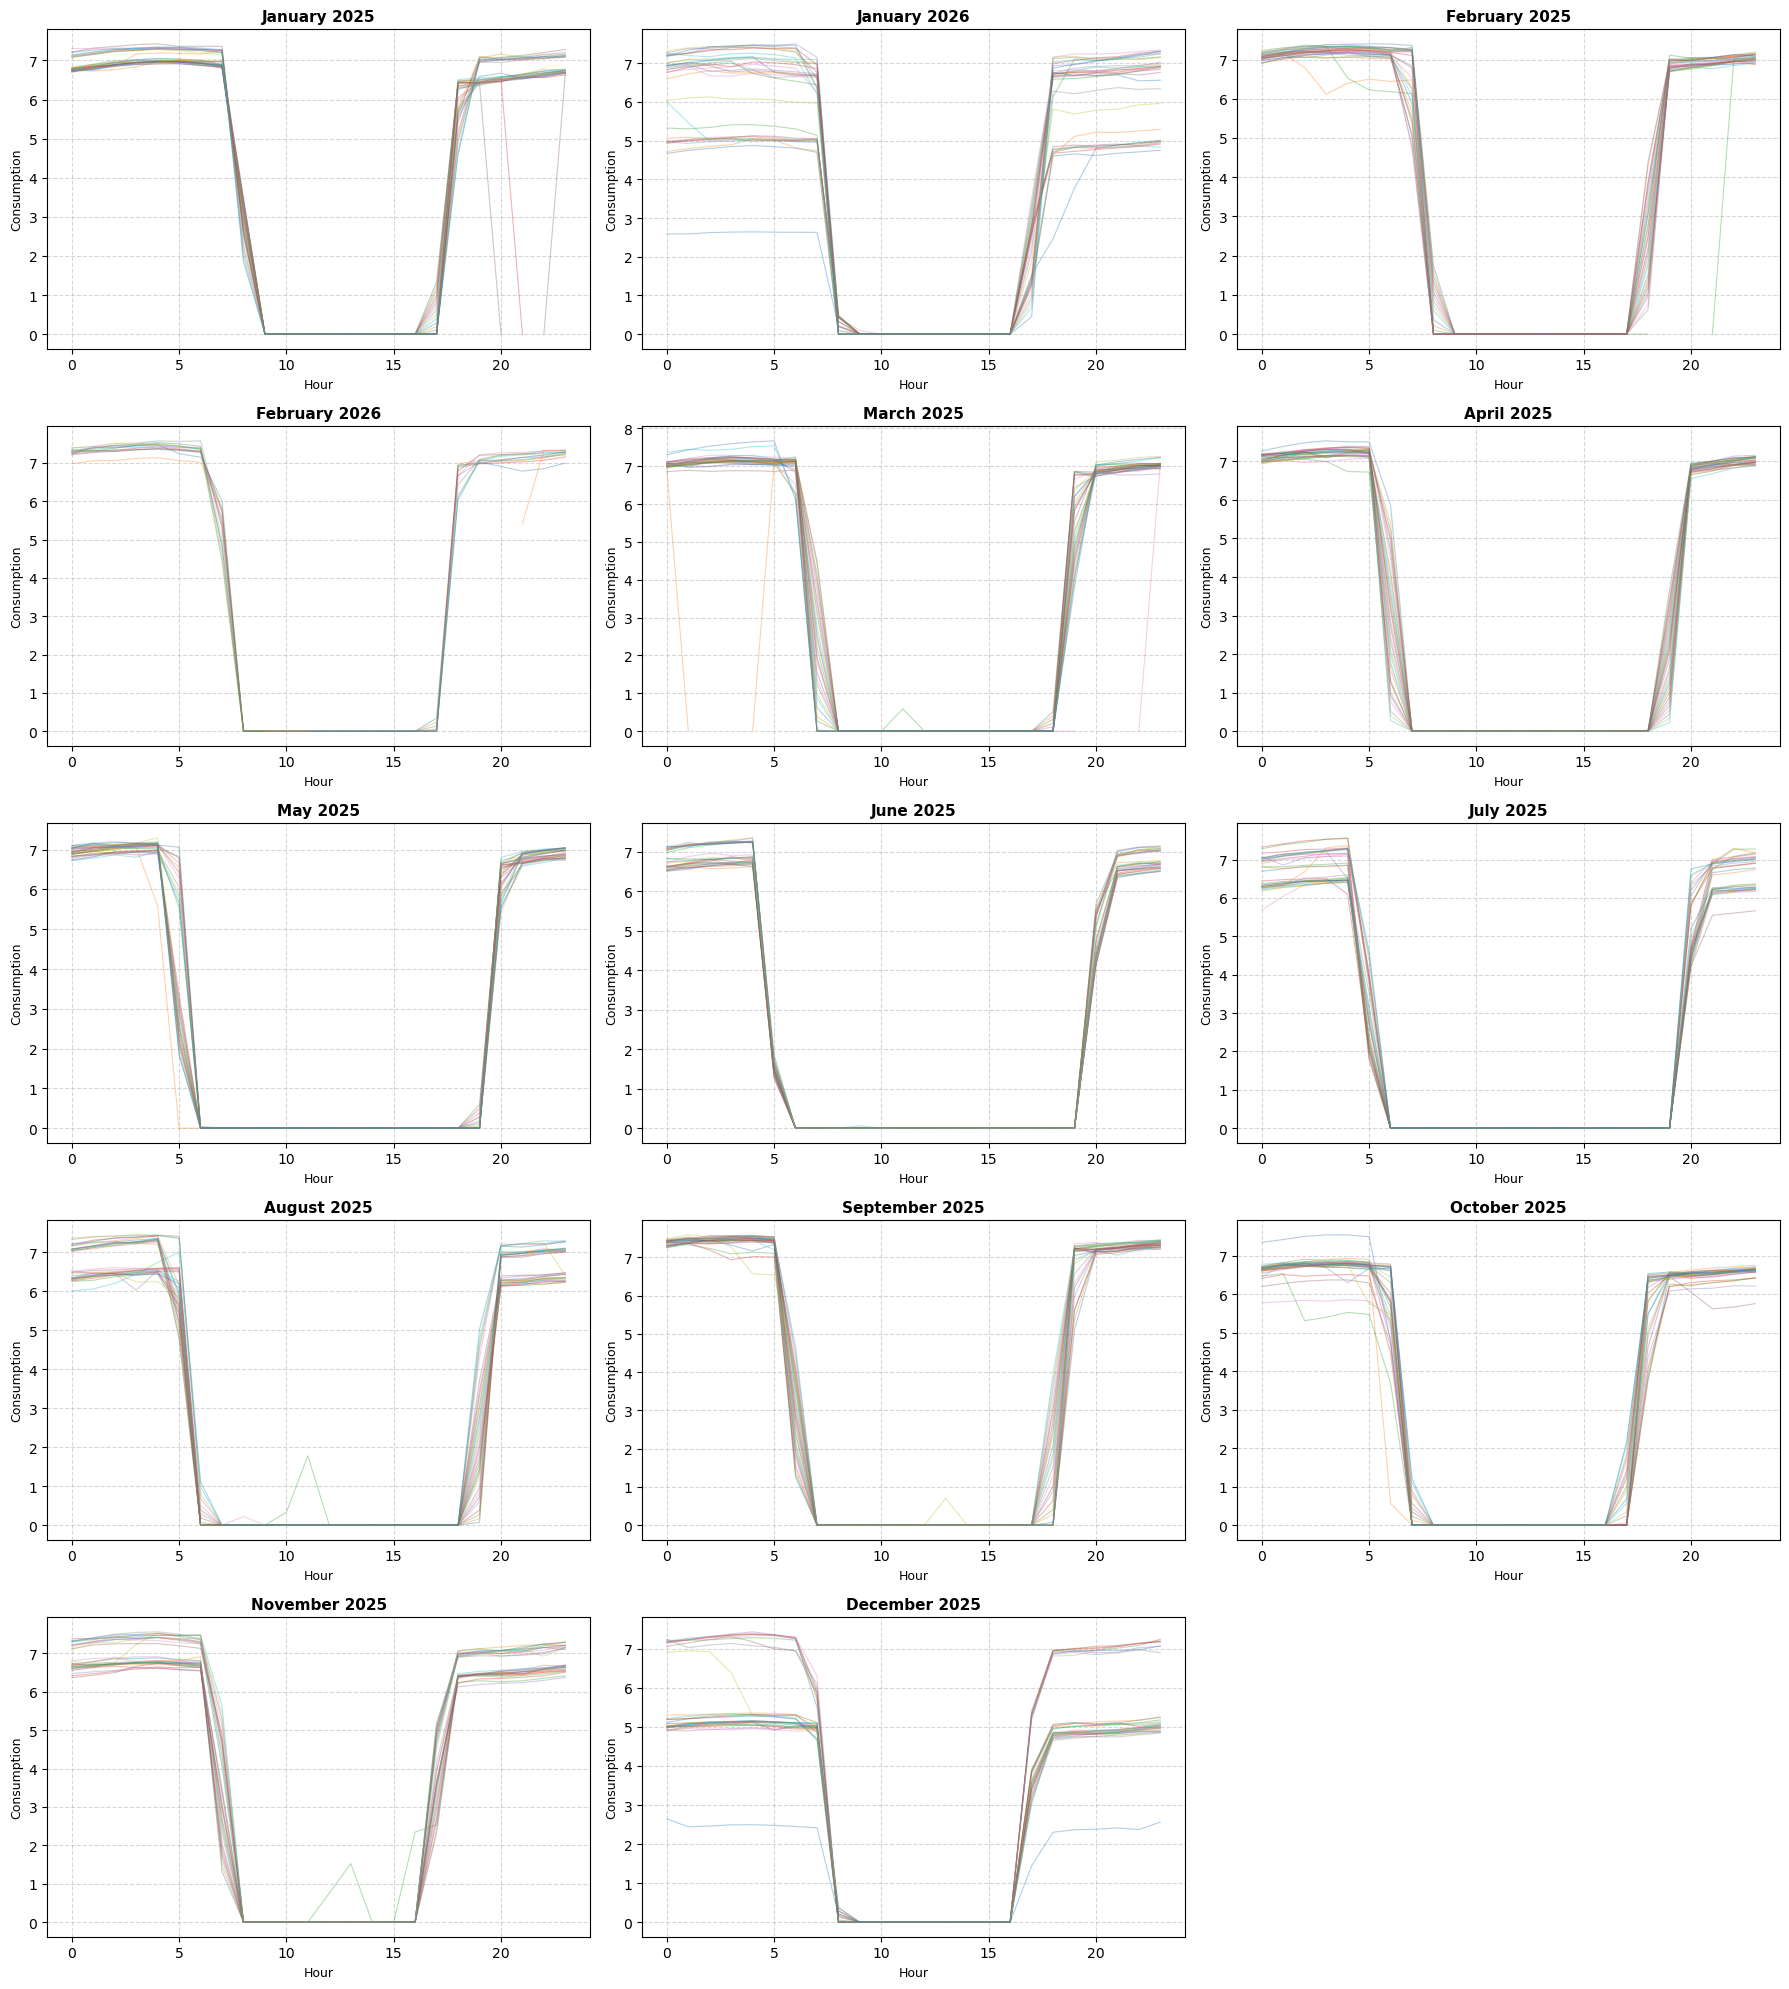

In [5]:
import matplotlib.pyplot as plt
import math

file_items = list(all_data.items())

n = len(file_items)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4 * nrows))
axes = axes.flatten()

for i, (file_name, df) in enumerate(file_items):
    ax = axes[i]

    # Sadece Çekiş satırları
    cekis = df[df["Veriş/Çekiş"] == "Çekiş"].copy()

    # Saat bilgisi
    cekis["hour"] = (
        cekis["Saat/Gün"]
        .astype(str)
        .str.extract(r"(\d{2})")[0]
        .astype(float)
    )

    cekis = cekis.dropna(subset=["hour"])
    cekis["hour"] = cekis["hour"].astype(int)

    # Gün kolonları
    day_cols = [c for c in cekis.columns if isinstance(c, int)]

    # Saat sırasına göre sırala
    cekis = cekis.sort_values("hour")

    # Çizim
    for day in day_cols:
        if cekis[day].notna().any():
            ax.plot(cekis["hour"], cekis[day], alpha=0.35, linewidth=0.8)

    # Dosya adından ay-yıl
    parts = file_name.split('_')
    ay_no = int(parts[0])
    yil_no = int(parts[1].split('.')[0])

    en_months = [
        "January", "February", "March", "April", "May", "June",
        "July", "August", "September", "October", "November", "December"
    ]
    month_name = en_months[ay_no - 1]

    ax.set_title(f"{month_name} {yil_no}", fontsize=11, fontweight='bold')
    ax.set_xlabel("Hour", fontsize=9)
    ax.set_ylabel("Consumption", fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.5)

# Boş kalan eksenleri kapat
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [6]:
import pandas as pd

combined_list = []

for file_name, df in all_data.items():
    # Sadece Çekiş satırlarını al
    cekis_df = df[df["Veriş/Çekiş"] == "Çekiş"].copy()

    # Saat bilgisini senin yazdığın mantıkla temizleyelim
    cekis_df["hour"] = (
        cekis_df["Saat/Gün"]
        .astype(str)
        .str.extract(r"(\d{2})")
        .astype(float)
    )
    cekis_df = cekis_df.dropna(subset=["hour"])
    cekis_df["hour"] = cekis_df["hour"].astype(int)

    # Gün kolonlarını (1, 2, 3...) bul
    day_cols = [c for c in cekis_df.columns if isinstance(c, int)]

    # Tabloyu "Geniş" formattan "Uzun" (ML dostu) formata çevir
    # Bu işlem her günü birer satır yapar
    df_melted = cekis_df.melt(
        id_vars=["hour", "Dosya_Kaynagi" if "Dosya_Kaynagi" in cekis_df.columns else "Veriş/Çekiş"],
        value_vars=day_cols,
        var_name="Gun",
        value_name="Cekis_Degeri"
    )

    # Hangi dosyadan geldiğini ekle (Dosya adından ay/yıl bilgisini korur)
    df_melted["Kaynak_Dosya"] = file_name
    combined_list.append(df_melted)

# İşte tanımlı olmayan o değişkeni şimdi oluşturuyoruz:
final_df = pd.concat(combined_list, ignore_index=True)

# Boş (NaN) değerleri temizle (Örneğin 30 çeken aylardaki 31. gün sütunları boş gelir)
#final_df = final_df.dropna(subset=["Cekis_Degeri"])

#print("final_df başarıyla oluşturuldu! Satır sayısı:", len(final_df))

In [7]:
# ── INTERPOLATION BLOĞU ──────────────────────────────────────────
# Timestamp oluştur
final_df["Gun"] = final_df["Gun"].astype(int)
final_df["year"] = final_df["Kaynak_Dosya"].str.extract(r"_(\d{4})").astype(int)
final_df["month"] = final_df["Kaynak_Dosya"].str.extract(r"^(\d{2})").astype(int)

final_df["timestamp"] = pd.to_datetime(
    dict(
        year=final_df["year"],
        month=final_df["month"],
        day=final_df["Gun"],
        hour=final_df["hour"]
    ),
    errors="coerce"
)
# ── BURAYA EKLE ──────────────────────────────────────
final_df = final_df.sort_values("timestamp")
final_df = final_df.groupby("timestamp").agg({
    "Cekis_Degeri": "mean",
    "Kaynak_Dosya": "first",
    "hour": "first",
    "Gun" : "first"
}).reset_index()
# ─────────────────────────────────────────────────────

final_df = final_df.set_index("timestamp")

full_index = pd.date_range(
    start=final_df.index.min(),
    end=final_df.index.max(),
    freq="h"
)
final_df = final_df.reindex(full_index)
final_df["Cekis_Degeri"] = final_df["Cekis_Degeri"].interpolate(method="time")
final_df["Kaynak_Dosya"] = final_df["Kaynak_Dosya"].ffill()

final_df.index.name = "timestamp"
final_df = final_df.reset_index()

print("Eksik değer kaldı mı:", final_df["Cekis_Degeri"].isna().sum())
print("Toplam satır:", len(final_df))

Eksik değer kaldı mı: 0
Toplam satır: 10176


In [8]:
final_df

,timestamp,Cekis_Degeri,Kaynak_Dosya,hour,Gun
0,2025-01-01 00:00:00,6.706,01_2025.xlsx,0,1
1,2025-01-01 01:00:00,6.770,01_2025.xlsx,1,1
2,2025-01-01 02:00:00,6.855,01_2025.xlsx,2,1
3,2025-01-01 03:00:00,6.915,01_2025.xlsx,3,1
4,2025-01-01 04:00:00,6.964,01_2025.xlsx,4,1
...,...,...,...,...,...
10171,2026-02-28 19:00:00,0.000,02_2026.xlsx,19,28
10172,2026-02-28 20:00:00,0.000,02_2026.xlsx,20,28
10173,2026-02-28 21:00:00,0.000,02_2026.xlsx,21,28
10174,2026-02-28 22:00:00,0.000,02_2026.xlsx,22,28


In [9]:
from sklearn.ensemble import IsolationForest

# Modeli kur (Grafiklerdeki aykırı çizgilerin yoğunluğuna göre %3 anomali oranı verdik)
model = IsolationForest(contamination=0.03, random_state=42)

# Modeli eğit ve tahmin et
final_df['is_anomaly'] = model.fit_predict(final_df[['hour', 'Cekis_Degeri']])

# Sonuçları kontrol et (-1 anomali demektir)
anomaliler = final_df[final_df['is_anomaly'] == -1]
print(f"Toplam {len(anomaliler)} adet anomali (arıza riski) tespit edildi.")

Toplam 306 adet anomali (arıza riski) tespit edildi.


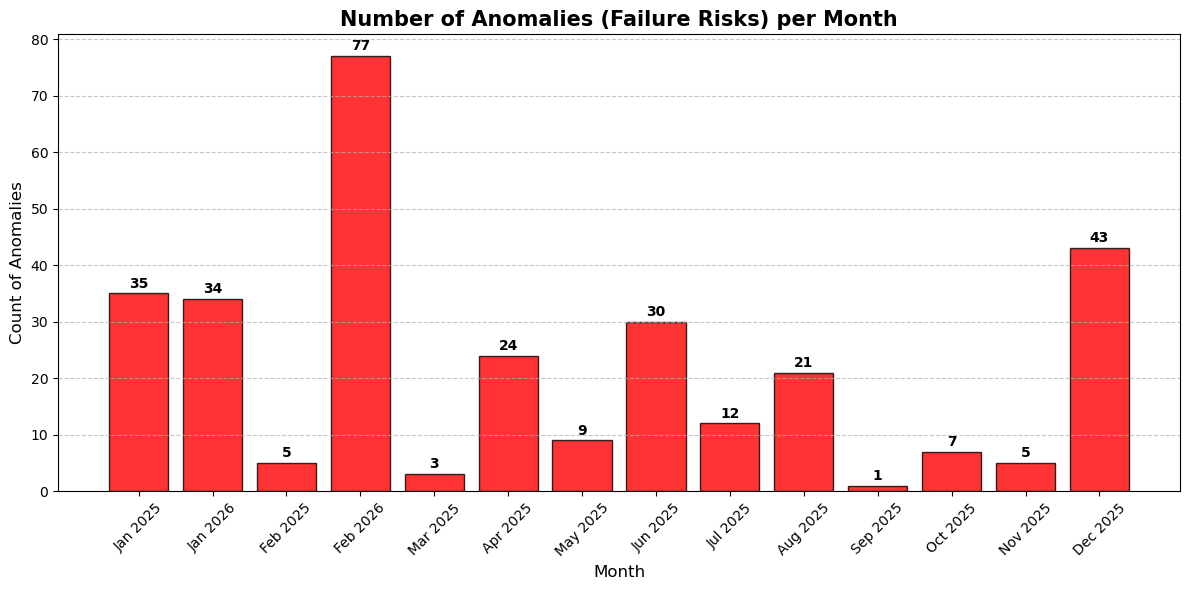

In [10]:
import matplotlib.pyplot as plt

# 1. İngilizce Ay Sözlüğü
month_map = {
    "01": "Jan", "02": "Feb", "03": "Mar", "04": "Apr", "05": "May", "06": "Jun",
    "07": "Jul", "08": "Aug", "09": "Sep", "10": "Oct", "11": "Nov", "12": "Dec"
}

# 2. Veriyi Hazırla ve İsimleri Temizle
anomali_dagilim = anomaliler['Kaynak_Dosya'].value_counts().sort_index()
# Dosya adından (01_2025.xlsx) sadece 'Jan 2025' kısmını oluşturuyoruz
clean_labels = [f"{month_map[i.split('_')[0]]} {i.split('_')[1][:4]}" for i in anomali_dagilim.index]

# 3. Görselleştirme
plt.figure(figsize=(12, 6))
bars = plt.bar(clean_labels, anomali_dagilim.values, color='red', edgecolor='black', alpha=0.8)

# Başlık ve Eksenler
plt.title("Number of Anomalies (Failure Risks) per Month", fontsize=15, fontweight='bold')
plt.xlabel("Month", fontsize=12)
plt.ylabel("Count of Anomalies", fontsize=12)
plt.xticks(rotation=45) # Yazıların birbirine girmemesi için eğiyoruz
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Çubukların üzerine sayıları yazdıralım (Hocan bunu çok beğenir!)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, int(yval), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

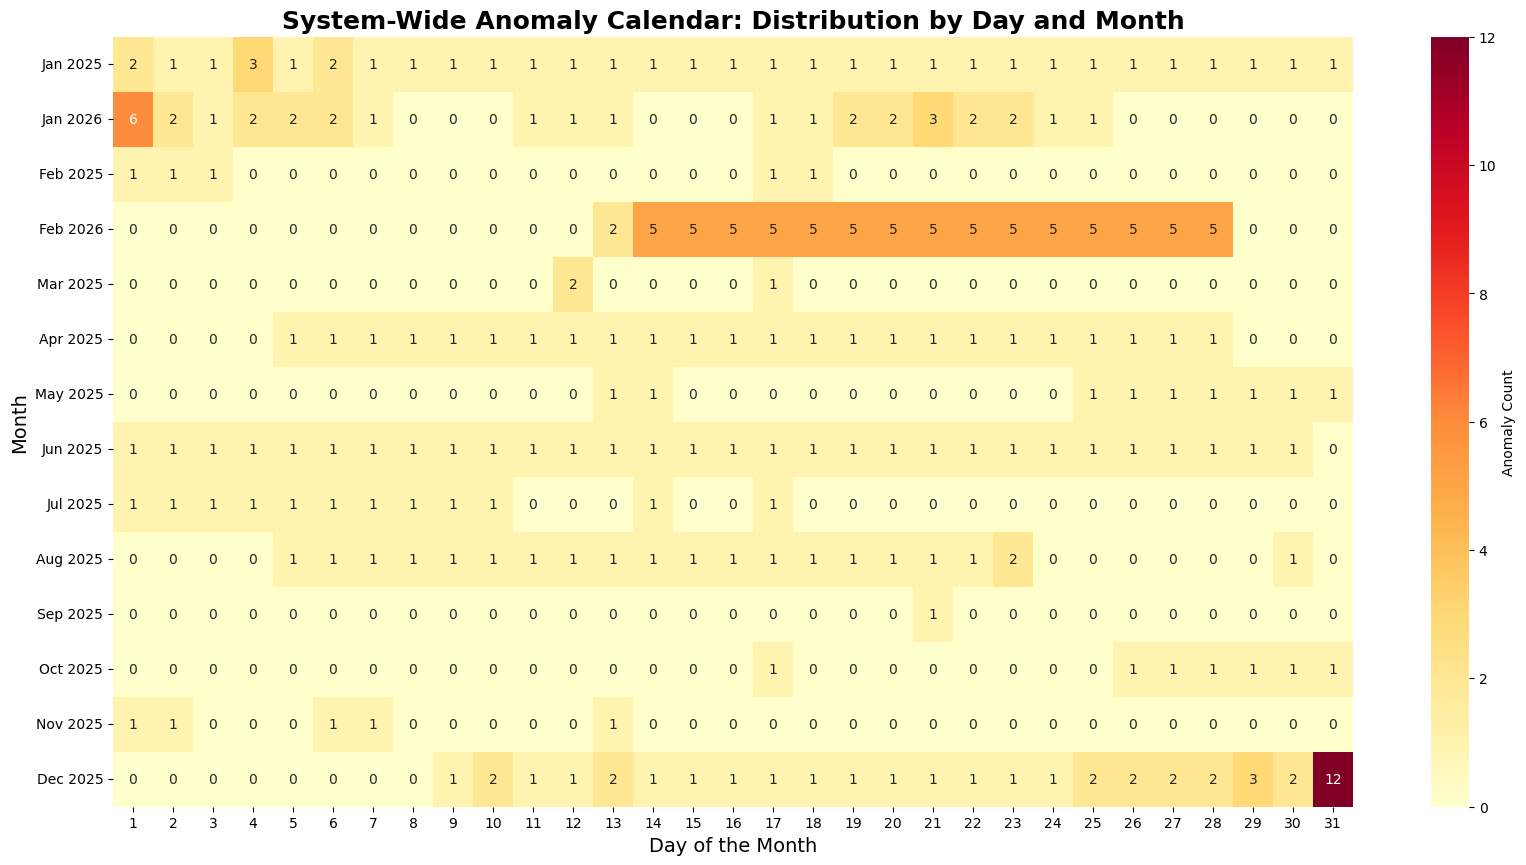

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Veriyi Hazırla: Ay ve Gün bazlı anomali sayılarını tabloya dök
# 'Kaynak_Dosya' ve 'Gun' üzerinden gruplayıp toplam anomali sayısını buluyoruz
heatmap_df = anomaliler.groupby(['Kaynak_Dosya', 'Gun']).size().unstack(fill_value=0)

# 2. Ay İsimlerini İngilizce ve Okunabilir Yap (01_2025.xlsx -> Jan 2025)
month_map = {
    "01": "Jan", "02": "Feb", "03": "Mar", "04": "Apr", "05": "May", "06": "Jun",
    "07": "Jul", "08": "Aug", "09": "Sep", "10": "Oct", "11": "Nov", "12": "Dec"
}
new_index = [f"{month_map[i.split('_')[0]]} {i.split('_')[1][:4]}" for i in heatmap_df.index]
heatmap_df.index = new_index

# 3. Görselleştirme
plt.figure(figsize=(20, 10))
sns.heatmap(heatmap_df, annot=True, fmt="d", cmap="YlOrRd", cbar_kws={'label': 'Anomaly Count'})

plt.title("System-Wide Anomaly Calendar: Distribution by Day and Month", fontsize=18, fontweight='bold')
plt.xlabel("Day of the Month", fontsize=14)
plt.ylabel("Month", fontsize=14)
plt.show()

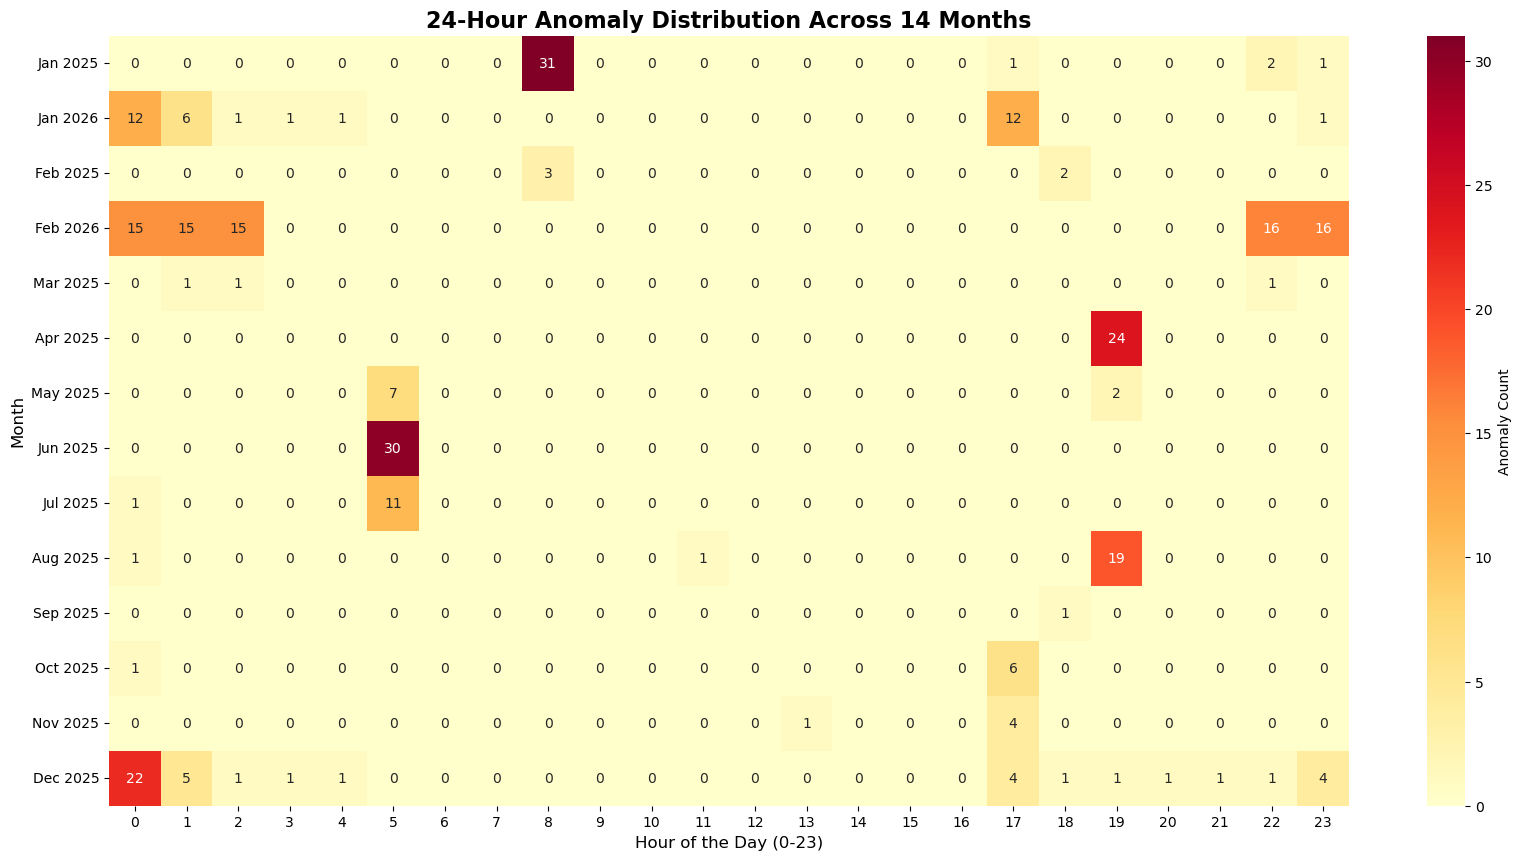

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Veriyi Hazırla
hourly_heatmap = anomaliler.groupby(['Kaynak_Dosya', 'hour']).size().unstack(fill_value=0)

# --- EKSİK SAATLERİ (12-16 arası vb.) 0 İLE DOLDURAN KISIM ---
# 0'dan 23'e kadar tüm saatlerin sütun olarak olmasını garanti ediyoruz
all_hours = list(range(24))
hourly_heatmap = hourly_heatmap.reindex(columns=all_hours, fill_value=0)
# -----------------------------------------------------------

# 2. Ay isimlerini İngilizce yap
month_map = {
    "01": "Jan", "02": "Feb", "03": "Mar", "04": "Apr", "05": "May", "06": "Jun",
    "07": "Jul", "08": "Aug", "09": "Sep", "10": "Oct", "11": "Nov", "12": "Dec"
}
new_index = [f"{month_map[i.split('_')[0]]} {i.split('_')[1][:4]}" for i in hourly_heatmap.index]
hourly_heatmap.index = new_index

# 3. Görselleştirme
plt.figure(figsize=(20, 10))
sns.heatmap(hourly_heatmap, annot=True, fmt="d", cmap="YlOrRd", cbar_kws={'label': 'Anomaly Count'})

plt.title("24-Hour Anomaly Distribution Across 14 Months", fontsize=16, fontweight='bold')
plt.xlabel("Hour of the Day (0-23)", fontsize=12)
plt.ylabel("Month", fontsize=12)
plt.show()

In [13]:
# Mevsim sütununu ekleyip ortalamalara bakalım
def get_season(month_str):
    month = int(month_str.split('_')[0])
    if month in [12, 1, 2]: return 'Kış'
    if month in [3, 4, 5]: return 'İlkbahar'
    if month in [6, 7, 8]: return 'Yaz'
    return 'Sonbahar'

final_df['Mevsim'] = final_df['Kaynak_Dosya'].apply(get_season)

# Mevsimsel anomali özeti
mevsim_ozet = final_df.groupby(['Mevsim', 'is_anomaly']).size().unstack()
print(mevsim_ozet)

is_anomaly   -1     1
Mevsim               
Kış         194  3382
Sonbahar     13  2171
Yaz          63  2145
İlkbahar     36  2172


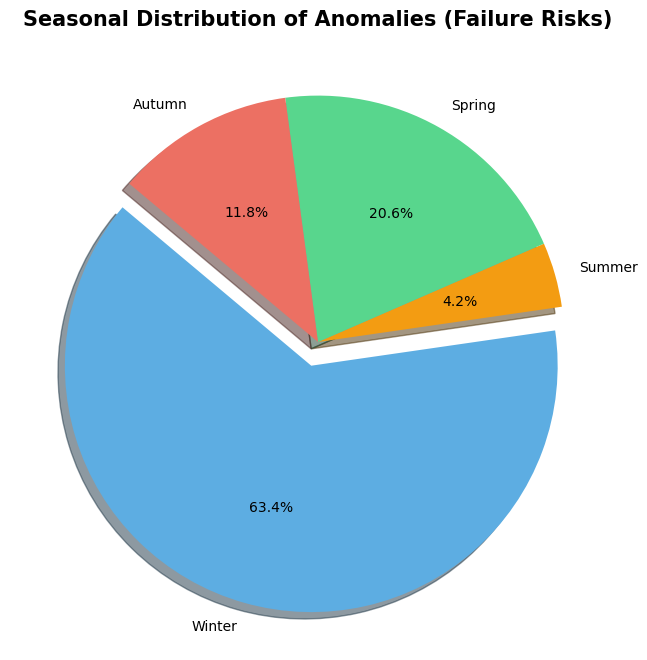

In [14]:
import matplotlib.pyplot as plt

# Mevsim isimlerini İngilizceye çeviriyoruz
# Not: mevsim_ozet index isimlerin 'Kış', 'Yaz' ise onları burada değiştiriyoruz
mevsim_labels = ['Winter', 'Summer', 'Spring', 'Autumn'] 

# Grafiği Çiz
plt.figure(figsize=(10, 8))
mevsim_ozet[-1].plot(
    kind='pie', 
    labels=mevsim_labels, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=['#5DADE2', '#F39C12', '#58D68D', '#EC7063'], # Daha profesyonel renk paleti
    explode=(0.1, 0, 0, 0), # Kış dilimini öne çıkarmak için (vurgu yapar)
    shadow=True
)

plt.title("Seasonal Distribution of Anomalies (Failure Risks)", fontsize=15, fontweight='bold')
plt.ylabel("") # Y ekseni ismini temizle
plt.show()